see eg. dev28 for how to pick rois

In [1]:
import importlib
import sys
from pathlib import Path

# Add mjosa_code root to path
mjosa_code_root = Path.cwd().parent  # Up to mjosa_code root
sys.path.insert(0, str(mjosa_code_root))

# Import from mjosa_code (NEW structure)
from utils.uhi import georef
from utils.common import config

importlib.reload(georef)
from utils.uhi.georef import *

In [2]:
# ========== TRANSECT 057 (DEFAULT) ==========
# Load transect 057
transect = load_transect(config.TRANSECT_057_OUTPUT)
transect.list_files()

# Select file from transect 057
cube = transect.select_files(["rad_uhi_20241029_115057_5"])
cube.describe()


📋 Files in output (corrected=False):
 1. rad_uhi_20241029_115057_1  | shape=(1333, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_115057_2  | shape=(1946, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_115057_3  | shape=(2227, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_115057_4  | shape=(2463, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_115057_5  | shape=(2462, 968, 210)  | has_georef=True
 6. rad_uhi_20241029_115057_6  | shape=(155, 968, 210)  | has_georef=True
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_115057_5...
✅ Loaded full cube: (2462, 968, 210) (T × S × B)

=== Combined_output ===
Tracks × Slits: 2462 × 968
RGB coverage: R/G/B finite ratios 1.00/1.00/1.00

📋 File boundaries:
  rad_uhi_20241029_115057_5: tracks 0–2461 (2462)


In [3]:
cube.list_saved_corrections()


📋 Cached illumination corrections:

📁 File: rad_uhi_20241029_115057_5
   ✓ window=unknown
     Dataset: dataCube_corrected_smoothed_gaussian_sig5p0
     Shape: (2462, 968, 210), Size: 1909.2 MB
   ✓ window=1000
     Dataset: dataCube_corrected_w1000
     Shape: (2462, 968, 210), Size: 1909.2 MB
   ✓ window=500
     Dataset: dataCube_corrected_w500
     Shape: (2462, 968, 210), Size: 1909.2 MB
   ✓ window=750
     Dataset: dataCube_corrected_w750
     Shape: (2462, 968, 210), Size: 1909.2 MB


In [4]:
# cube.rename_legacy_corrections()  # Will ask for confirmation

In [5]:
cube.apply_illumination_correction_v2(window_size=500, force_recompute=False)

🔄 Using V2 algorithm (pandas rolling median, memory-efficient)
✅ Illumination correction already applied with window=500, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 1 files...
   rad_uhi_20241029_115057_5: window=500, strength=1.0
✅ Loaded illumination correction from disk


array([[[2.2304249e+00, 1.6764377e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.0077596e+00, 0.0000000e+00],
        [7.4757171e+00, 8.5974735e-01, 0.0000000e+00, ...,
         0.0000000e+00, 3.0958059e+00, 0.0000000e+00],
        [1.8294926e+00, 2.3438740e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.1090145e+00, 0.0000000e+00],
        ...,
        [1.7213115e+00, 1.4317783e+00, 0.0000000e+00, ...,
         1.0000000e+00, 2.3279436e-02, 3.7040919e-01],
        [5.8812752e+00, 2.0123754e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.4956644e+00, 0.0000000e+00],
        [2.3867478e+00, 1.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.5736811e+01, 4.5105180e-01]],

       [[2.2304249e+00, 7.7452070e-01, 3.9940205e+00, ...,
         0.0000000e+00, 0.0000000e+00, 9.6023534e-05],
        [1.7471981e+00, 0.0000000e+00, 1.2654871e+00, ...,
         0.0000000e+00, 8.5029960e-01, 6.3767982e-01],
        [1.9216584e+00, 0.0000000e+00, 3.0771544e+00, ...,
         0.000

In [6]:
cube.adjust_uhi_alignment(dx=-0.05, dy=-3.0)

✅ UHI alignment adjusted:
   dx (East):  -0.050 m
   dy (North): -3.000 m

💡 This will be applied in plot_georef() with coordinate_system='NED'


In [7]:
# Import ROIs from file
# cube.import_rois("rois/057_5_combined.json")
cube.import_rois("rois/057_5_many_classes.json")

📂 Imported 18 ROIs from rois/057_5_many_classes.json


In [8]:
# List all ROIs
cube.list_rois()


📂 ROI Collection (18 ROIs):
 1. 'yellow leaf': 19 pixels
     Slit range:  756 - 779
     Track range: 2100 - 2103
 2. 'brown leaf': 33 pixels
     Slit range:  756 - 782
     Track range: 1770 - 1776
 3. 'dark sediment': 120 pixels
     Slit range:  254 - 325
     Track range: 931 - 1416
 4. 'dark1': 98 pixels
     Slit range:  606 - 740
     Track range: 729 - 765
 5. 'dark2': 140 pixels
     Slit range:  174 - 356
     Track range: 1094 - 1148
 6. 'sediment': 273 pixels
     Slit range:   14 - 870
     Track range: 577 - 1580
 7. 'dark bomb': 238 pixels
     Slit range:  174 - 740
     Track range: 729 - 1148
 8. 'tripple bomb 1': 71 pixels
     Slit range:  662 - 701
     Track range: 593 - 598
 9. 'tripple bomb 2': 42 pixels
     Slit range:  639 - 654
     Track range: 700 - 705
10. 'tripple bomb 3': 84 pixels
     Slit range:  632 - 678
     Track range: 757 - 765
11. 'single bomb ring': 62 pixels
     Slit range:  224 - 404
     Track range: 1124 - 1168
12. 'single bomb inside

In [9]:
roi_totals = [
    "sediment",
    "dark spots",
    "all bombs",
]

roi_names = [
    "double bomb 2",
    "double bomb 1",
    "tripple bomb 1",
    "tripple bomb 2",
    "tripple bomb 3",
    "single bomb ring",
    "single bomb inside",
    "dark sediment",
    "dark bomb",
    "sediment",
]

🔧 DEBUG: plot_georef called with use_wavelength_colormap=False, wavelength_colormap_target=None
💡 Interactive mode: Click on the plot to display coordinates


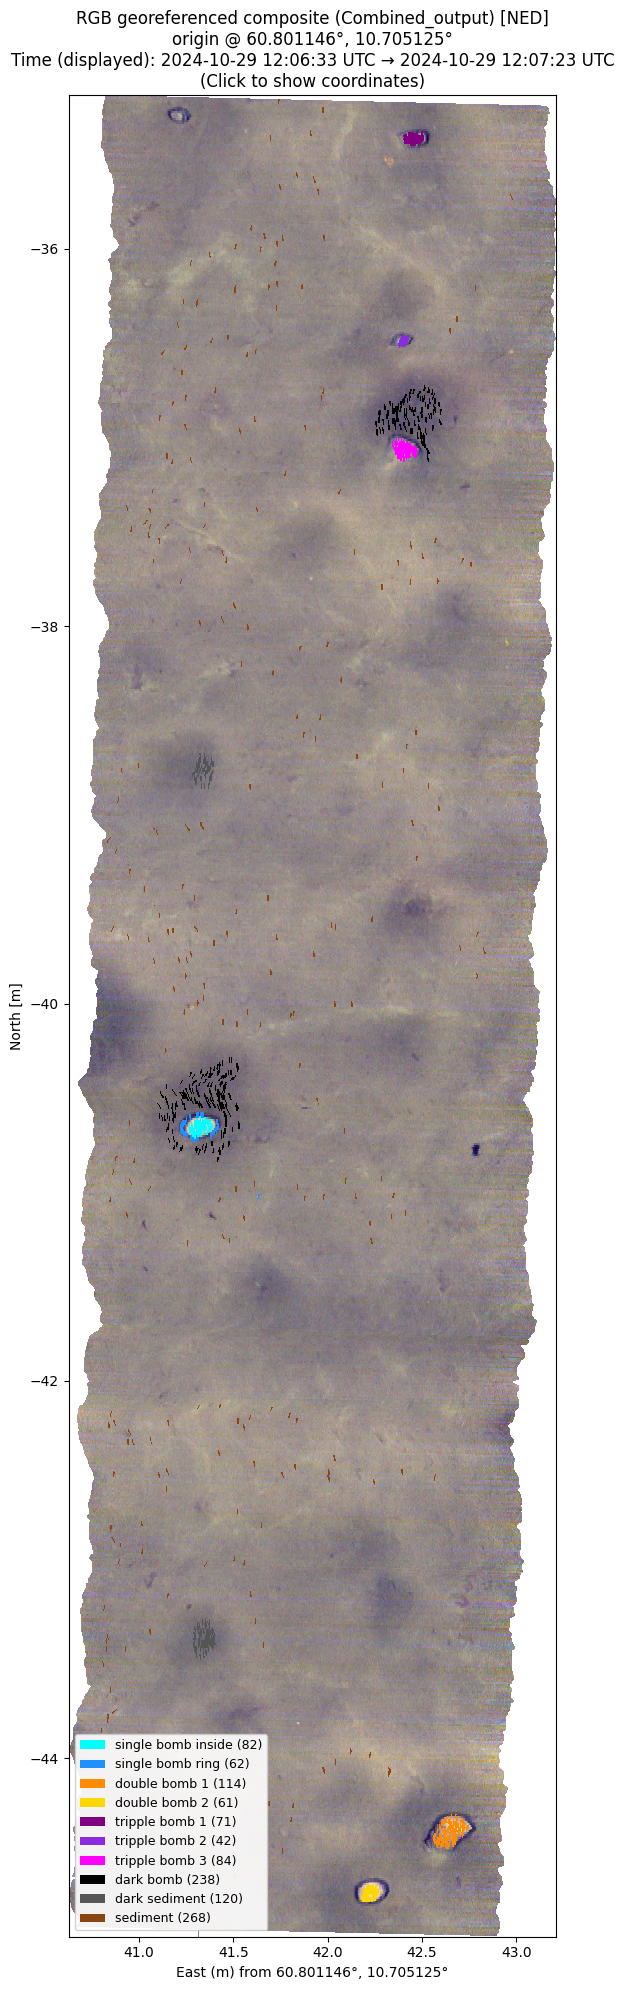

🔧 DEBUG: plot_georef called with use_wavelength_colormap=False, wavelength_colormap_target=None
💡 Interactive mode: Click on the plot to display coordinates


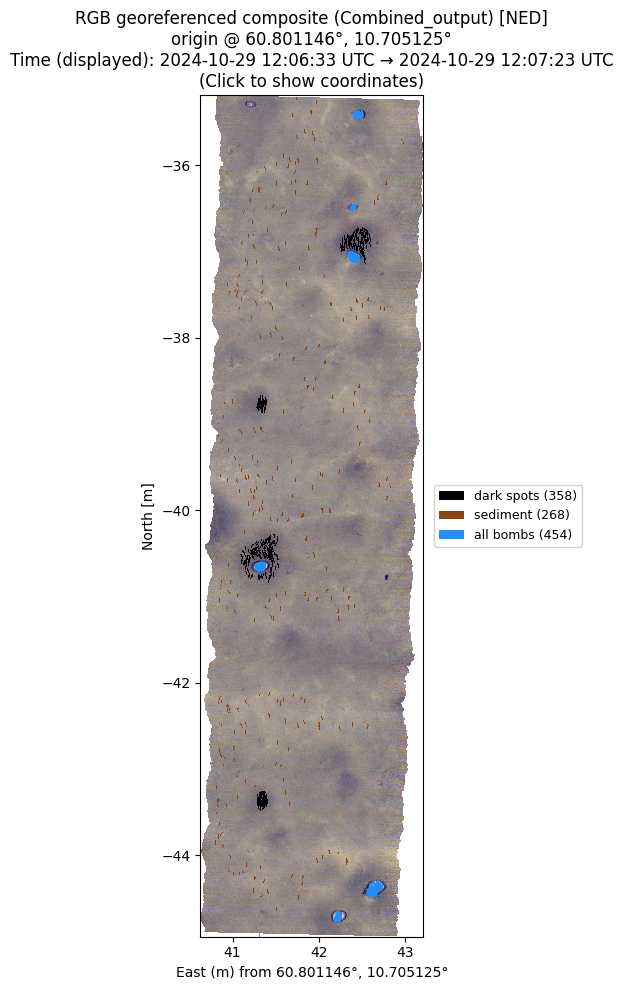

In [10]:
cube.plot_georef(
    apply_alignment_shift=True,
    use_corrected=True,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    figsize=(50, 20),
    roi_collection=roi_names,
    roi_legend_loc="lower left",  # Changed from "outside" to "lower left"
    roi_solid_pixel_size=3,
    roi_overlay_mode="solid",
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
)

cube.plot_georef(
    apply_alignment_shift=True,
    use_corrected=True,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    figsize=(30, 10),
    roi_collection=roi_totals,
    # roi_legend_loc="lower left",  # Changed from "outside" to "lower left"
    roi_legend_loc="outside",  # Changed from "outside" to "lower left"
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
    roi_overlay_mode="solid",
    roi_solid_pixel_size=5,
)

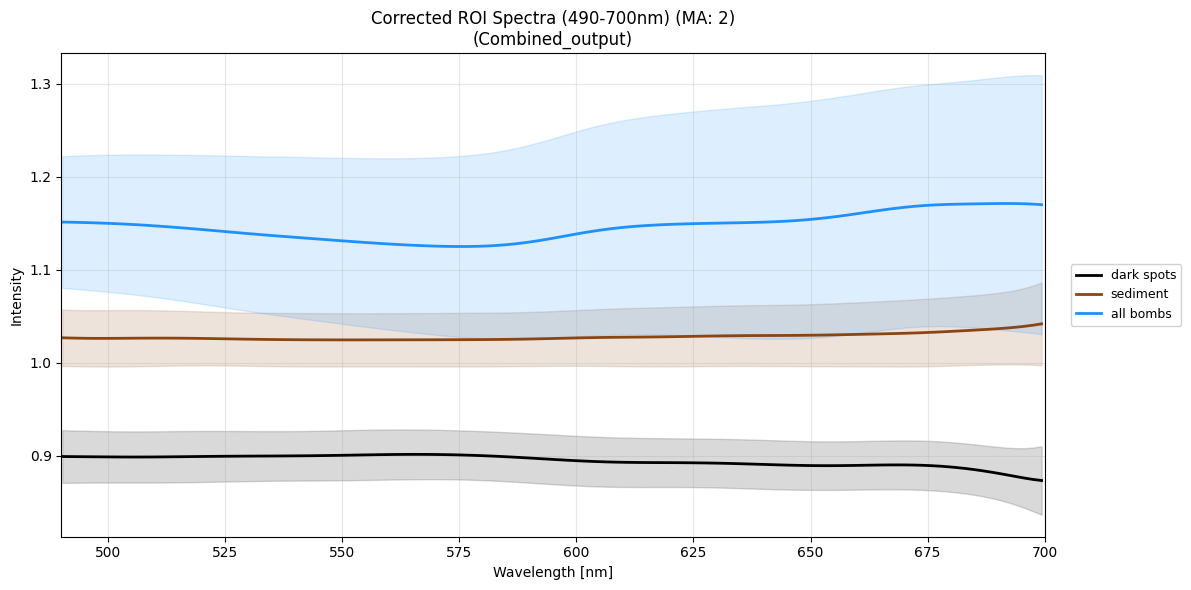

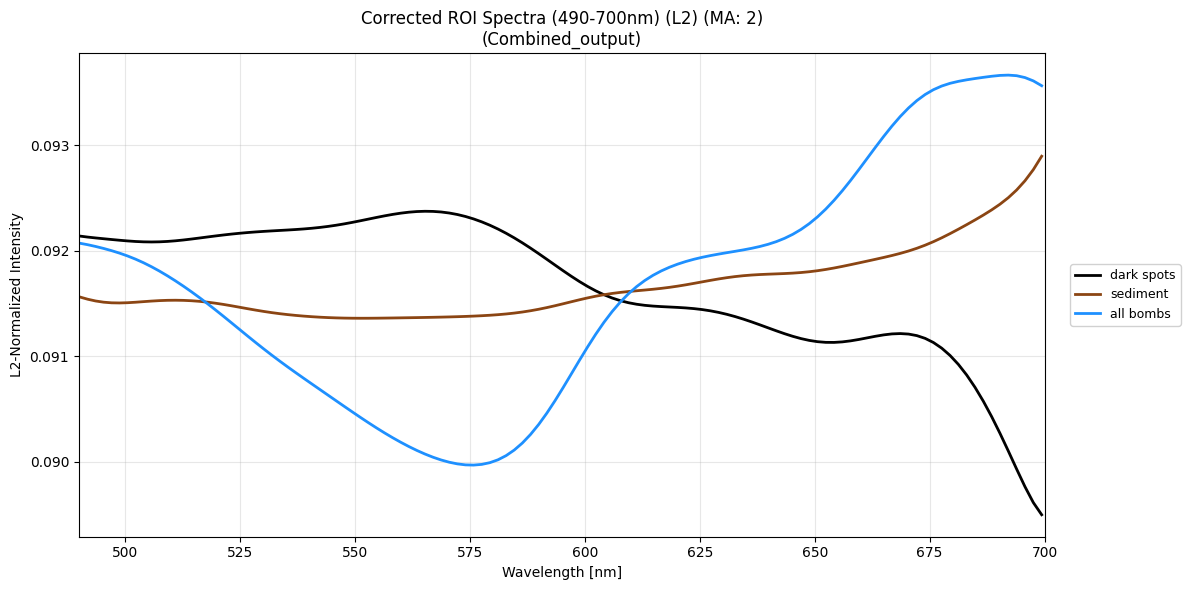

In [11]:
# Plot preprocessed spectra (no additional processing - already done)
cube.plot_spectrum(
    roi_names=roi_totals,
    use_corrected=True,
    wavelength_range=[490, 700],  # Already cropped in memory
    interpolate_wavelengths=None,  # Already interpolated in memory
    normalize_method=None,  # Already normalized in memory
    show_std=True,
    smoothing_method="gaussian",
    gaussian_sigma=5,
    smooth_before_filter=True,
    wavelength_smoothing=2,
)

# Plot preprocessed spectra (no additional processing - already done)
cube.plot_spectrum(
    roi_names=roi_totals,
    use_corrected=True,
    wavelength_range=[490, 700],  # Already cropped in memory
    interpolate_wavelengths=None,  # Already interpolated in memory
    normalize_method="l2",  # Already normalized in memory
    show_std=False,
    smoothing_method="gaussian",
    gaussian_sigma=5,
    smooth_before_filter=True,
    wavelength_smoothing=2,
)

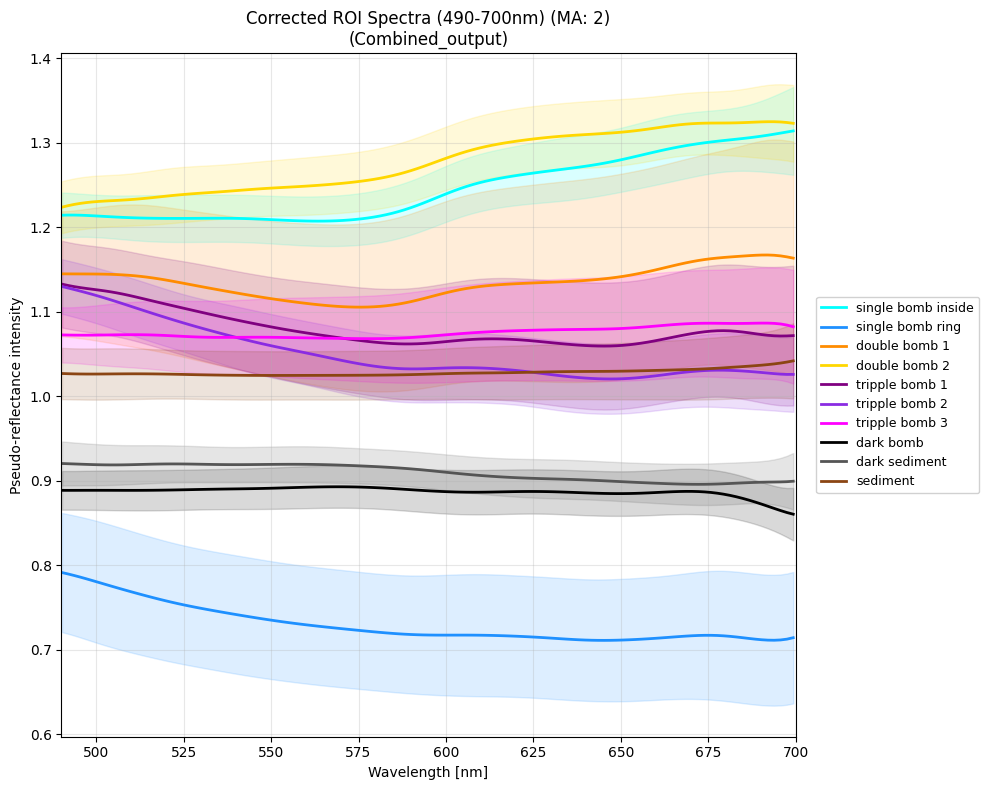

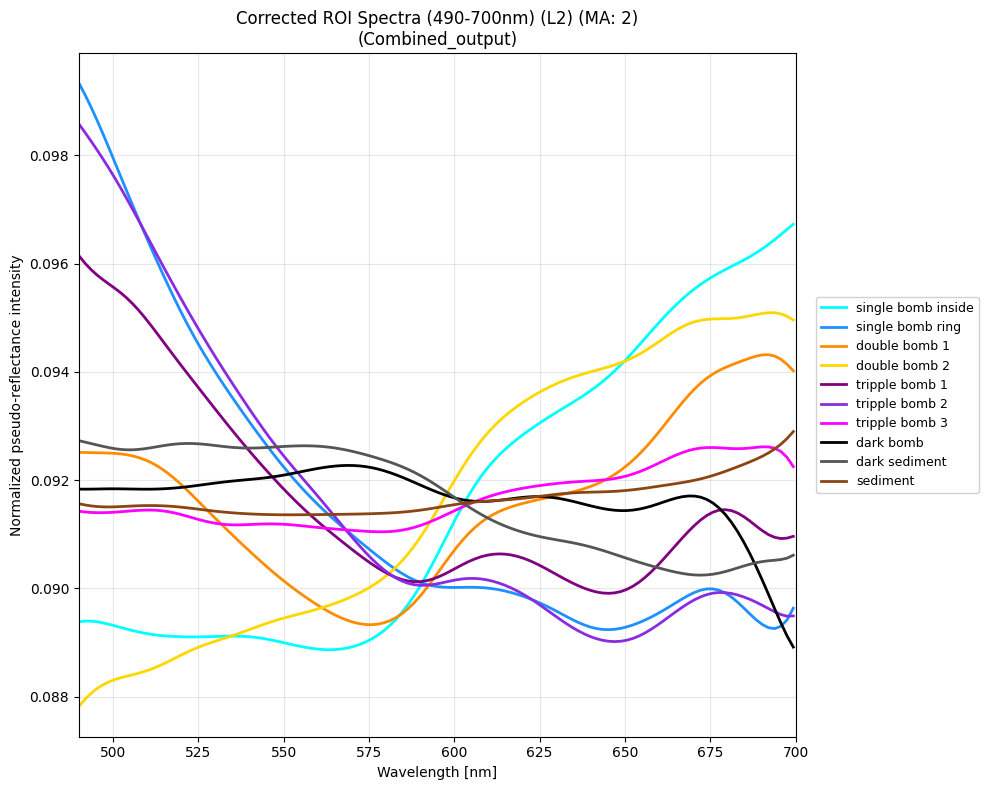

In [12]:
# Plot preprocessed spectra (no additional processing - already done)
cube.plot_spectrum(
    roi_names=roi_names,
    use_corrected=True,
    wavelength_range=[490, 700],  # Already cropped in memory
    interpolate_wavelengths=None,  # Already interpolated in memory
    normalize_method=None,  # Already normalized in memory
    show_std=True,
    smoothing_method="gaussian",
    gaussian_sigma=5,
    smooth_before_filter=True,
    wavelength_smoothing=2,
    figsize=(10, 8),
    ylabel="Pseudo-reflectance intensity",  # Custom y-axis label
)

cube.plot_spectrum(
    roi_names=roi_names,
    use_corrected=True,
    wavelength_range=[490, 700],  # Already cropped in memory
    interpolate_wavelengths=None,  # Already interpolated in memory
    normalize_method="l2",  # Already normalized in memory
    show_std=False,
    smoothing_method="gaussian",
    gaussian_sigma=5,
    smooth_before_filter=True,
    wavelength_smoothing=2,
    figsize=(10, 8),
    ylabel="Normalized pseudo-reflectance intensity",  # Custom y-axis label
)